In [9]:
import os
from langchain_core.prompts import PromptTemplate
from langchain.chat_models import init_chat_model
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


In [10]:
os.environ["AZURE_OPENAI_API_KEY"] = os.getenv("AZURE_OPENAI_API_KEY")
os.environ["AZURE_OPENAI_ENDPOINT"] = os.getenv("AZURE_OPENAI_ENDPOINT")
os.environ["OPENAI_API_VERSION"] = os.getenv("OPENAI_GPT_API_VERSION")

model = init_chat_model("azure_openai:gpt-5-mini")

In [11]:
class BlogState(TypedDict):
    topic: str
    outline: str
    blog: str

graph = StateGraph(BlogState)

def gen_outline(state: BlogState) -> BlogState:
    topic = state['topic']

    template = PromptTemplate(
        template="Generate the only outline of the topic mentioned below:\n{topic}\n THERE SHOULD BE ONLY OUTLINE/TOPICS",
        input_variables=['topic']
    )
    prompt = template.invoke({'topic': topic})

    outline = model.invoke(prompt).content
    state['outline'] = outline
    return state

def gen_blog(state: BlogState) -> BlogState:
    topic = state['topic']
    outline = state['outline']

    template = PromptTemplate(
        template="Generate a detailed blog on the topic of {topic} strictly based on the following outline:\n{outline}",
        input_variables=['topic', 'outline']
    )
    prompt = template.invoke({'topic': topic, 'outline': outline})

    blog = model.invoke(prompt).content
    state['blog'] = blog
    return state

graph.add_node('gen_outline', gen_outline)
graph.add_node('gen_blog', gen_blog)

graph.add_edge(START, 'gen_outline')
graph.add_edge('gen_outline', 'gen_blog')
graph.add_edge('gen_blog', END)

{'topic': 'LangGraph', 'outline': '1. Overview of LangGraph\n  1.1 Definition and core concept\n  1.2 Goals and scope\n  1.3 Key differentiators and related paradigms\n\n2. Motivation and Use Cases\n  2.1 Problems addressed\n  2.2 Target application domains\n  2.3 Example scenarios\n\n3. Conceptual Model\n  3.1 Node types (tokens, entities, concepts)\n  3.2 Edge types (syntactic, semantic, discourse, pragmatic)\n  3.3 Attributes, metadata, and provenance\n  3.4 Contextual and temporal layers\n\n4. Data Sources and Preprocessing\n  4.1 Text corpora and knowledge bases\n  4.2 Annotation schemas and labeling workflows\n  4.3 Tokenization, parsing, NER, coreference resolution\n  4.4 Graph construction heuristics and pipelines\n\n5. Graph Representations and Storage\n  5.1 Property graphs vs RDF/triple stores\n  5.2 Schema design and ontology integration\n  5.3 Indexing, compression, and partitioning\n  5.4 Databases and infrastructure choices\n\n6. Integration with Language Models\n  6.1 G

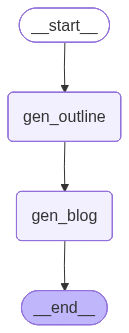

In [17]:
workflow = graph.compile()

initial_state = {
    'topic': 'LangGraph'
}

final_state = workflow.invoke(initial_state)
print(final_state)
graph.compile()

In [18]:
print(final_state['outline'])

1. Overview of LangGraph
  1.1 Definition and core concept
  1.2 Goals and scope
  1.3 Key differentiators and related paradigms

2. Motivation and Use Cases
  2.1 Problems addressed
  2.2 Target application domains
  2.3 Example scenarios

3. Conceptual Model
  3.1 Node types (tokens, entities, concepts)
  3.2 Edge types (syntactic, semantic, discourse, pragmatic)
  3.3 Attributes, metadata, and provenance
  3.4 Contextual and temporal layers

4. Data Sources and Preprocessing
  4.1 Text corpora and knowledge bases
  4.2 Annotation schemas and labeling workflows
  4.3 Tokenization, parsing, NER, coreference resolution
  4.4 Graph construction heuristics and pipelines

5. Graph Representations and Storage
  5.1 Property graphs vs RDF/triple stores
  5.2 Schema design and ontology integration
  5.3 Indexing, compression, and partitioning
  5.4 Databases and infrastructure choices

6. Integration with Language Models
  6.1 Graph-informed embeddings and encoding
  6.2 Retrieval-augmented 

In [19]:
print(final_state['blog'])

1. Overview of LangGraph

1.1 Definition and core concept
- LangGraph is a graph-centric approach to representing, reasoning about, and augmenting natural language understanding systems. At its core, LangGraph models linguistic elements (tokens, phrases, entities, concepts, discourse units) as nodes and the relationships between them (syntactic links, semantic relations, discourse links, pragmatic/contextual ties) as edges, capturing multi-granular structure and provenance in a unified graph substrate.
- The construct is intentionally multimodal-ready: nodes and edges carry attributes (text spans, embeddings, timestamps, sources) enabling tight integration with statistical models (embeddings, GNNs) and symbolic systems (logical rules, query languages).

1.2 Goals and scope
- Goals:
  - Make latent structure in text explicit, queryable, and updatable.
  - Combine symbolic, probabilistic, and neural methods for richer inference.
  - Provide reusable, persistent memory and context for lan